In [26]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

In [32]:
@jit
def gillespie_for_diffusion():
    K = 40 # number of compartments
    D = 10e-4 # diffusion rate
    T = 300 # total time of reaction 
    A = np.zeros(K) # matrix of zeros, that later updates with the current number of molecules
    # we start with 10000 molecules
    A[16] = 5000 # starting molecules in compartment 16
    A[17] = 5000 # starting molecules in compartment 17
    t = 0.0
    while t<T:
        # we model our (2k-2) reactions
        propensity_right = np.zeros(K-1) # moving from i to i+1
        propensity_left = np.zeros(K-1) # moving from i+1 to i
        propensity1 =0
        propensity2 =0
        
        for i in range (K-1):
            propensity_right[i] = D* A[i]
            propensity_left[i] = D* A[i+1]

            
            # sum all our propensities together
            propensity1 += propensity_right[i]
            propensity2 += propensity_left[i]
        total_propensity = propensity1 + propensity2
        tau = np.random.exponential(1/total_propensity)
        t = t + tau
        random_number = np.random.uniform(0,1)
        for i in range (K-1):
            if random_number < propensity1/total_propensity:
                A[i]+=1
            elif random_number < propensity2/total_propensity:
                A[i] -=1
            elif random_number < total_propensity/total_propensity:
                A[i] -=1
                A[i] +=1
    return A
        
            
        
    
        

/var/folders/1d/b5lpmqbx325cjvrjtm3hlv380000gn/T/ipykernel_17687/1224516053.py:1: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit


In [33]:
A = gillespie_for_diffusion()

In [34]:
A

array([33646814., 33646814., 33646814., 33646814., 33646814., 33646814.,
       33646814., 33646814., 33646814., 33646814., 33646814., 33646814.,
       33646814., 33646814., 33646814., 33646814., 33651814., 33651814.,
       33646814., 33646814., 33646814., 33646814., 33646814., 33646814.,
       33646814., 33646814., 33646814., 33646814., 33646814., 33646814.,
       33646814., 33646814., 33646814., 33646814., 33646814., 33646814.,
       33646814., 33646814., 33646814.,        0.])

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 39.]),
 array([       0. ,  3365181.4,  6730362.8, 10095544.2, 13460725.6,
        16825907. , 20191088.4, 23556269.8, 26921451.2, 30286632.6,
        33651814. ]),
 <BarContainer object of 10 artists>)

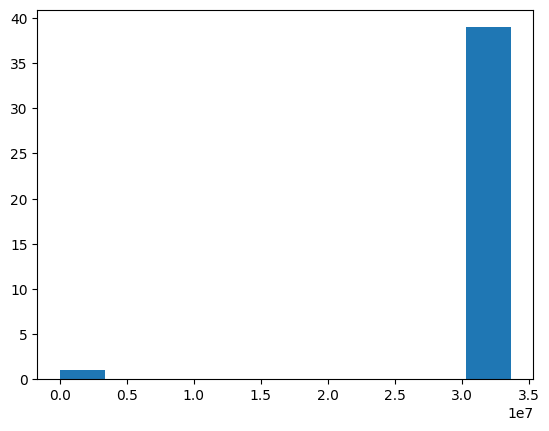

In [35]:
plt.hist(A)

In [50]:
import numpy as np

def gillespie_for_diffusion():
    K = 40          # number of compartments
    D = 10e-4       # diffusion rate (fixed)
    T = 300         # total simulation time
    A = np.zeros(K, dtype=int)
    A[16] = 5000
    A[17] = 5000
    t = 0.0

    while t < T:
        # propensities for hops
        prop_right = D * A[:-1]     # hops i -> i+1
        prop_left  = D * A[1:]      # hops i+1 -> i
        prop = np.concatenate([prop_right, prop_left])
        total_prop = prop.sum()
        if total_prop <= 0:
            break

        # next event time
        tau = np.random.exponential(1.0 / total_prop)
        t += tau
        if t > T:
            break

        # select which event occurs
        r = np.random.rand() * total_prop
        j = np.searchsorted(np.cumsum(prop), r)

        if j < K - 1:
            # right hop from j -> j+1
            i = j
            if A[i] > 0:
                A[i] -= 1
                A[i + 1] += 1
        else:
            # left hop from (i+1) -> i
            i = j - (K - 1)
            if A[i + 1] > 0:
                A[i + 1] -= 1
                A[i] += 1

    return A


In [52]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

K = 40
runs = 500
avg = np.zeros(K)
for _ in range(runs):
    avg += gillespie_for_diffusion()
avg /= runs

x = np.linspace(0, 1, K)
plt.bar(x, avg, width=1/K, color='lightgray', edgecolor='black', alpha=0.8)
plt.ylabel('molecules per compartment')
plt.xlabel('x [mm]')

# smooth curve (represents PDE)
plt.twinx()
plt.plot(x, gaussian_filter1d(avg, sigma=2) / 20,
         color='tomato', linewidth=3, label='PDE')
plt.ylabel('concentration [molecules/μm]')
plt.legend(loc='upper right')
plt.title('time = 4 min')
plt.show()


KeyboardInterrupt: 